In [92]:
# Cell 1: Imports and Optimized MR-gNODE Implementation
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Set device for GPU acceleration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Import tqdm for progress bars if available
try:
    from tqdm import tqdm
except ImportError:
    def tqdm(x, desc=None):
        print(f"{desc}..." if desc else "Processing...")
        return x

class BasicMRgNODE(nn.Module):
    """
    Multi-Region gated Neural ODE with Hierarchical Penalty Structure
    """
    
    def __init__(self, num_regions=2, region_dim=32, input_dim=2, latent_dim=16, tau=0.01):
        super().__init__()
        self.num_regions = num_regions
        self.region_dim = region_dim
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.tau = tau
        
        # Flow networks for each region
        self.flow_nets = nn.ModuleList([
            nn.Sequential(
                nn.Linear(region_dim + input_dim + region_dim, 32),
                nn.Tanh(),
                nn.Linear(32, region_dim)
            ) for _ in range(num_regions)
        ])
        
        # Gating networks for each region
        self.gate_nets = nn.ModuleList([
            nn.Sequential(
                nn.Linear(region_dim + input_dim + region_dim, 32),
                nn.Tanh(),
                nn.Linear(32, region_dim),
                nn.Sigmoid()
            ) for _ in range(num_regions)
        ])
        
        # Communication weights (vectorized)
        self.comm_weights = nn.Parameter(torch.randn(num_regions, num_regions, region_dim, region_dim))
        
        # Communication gating networks
        self.comm_gate_net = nn.Sequential(
            nn.Linear(2 * region_dim, 16),
            nn.Tanh(),
            nn.Linear(16, region_dim),
            nn.Sigmoid()
        )
        
        # Rate readout networks
        self.rate_nets = nn.ModuleList([
            nn.Linear(region_dim, region_dim)
            for _ in range(num_regions)
        ])
        
        # Variational latent communication
        self.latent_encoder_mu = nn.Sequential(
            nn.Linear(num_regions * region_dim, 32),
            nn.Tanh(),
            nn.Linear(32, latent_dim)
        )
        
        self.latent_encoder_logvar = nn.Sequential(
            nn.Linear(num_regions * region_dim, 32),
            nn.Tanh(),
            nn.Linear(32, latent_dim)
        )
        
        self.latent_decoders = nn.ModuleList([
            nn.Sequential(
                nn.Linear(latent_dim, 16),
                nn.Tanh(),
                nn.Linear(16, region_dim)
            ) for _ in range(num_regions)
        ])

        self.apply(self._init_weights)
        
        # Pre-compute communication mask (exclude self-connections)
        self.register_buffer('comm_mask', 
                           torch.ones(num_regions, num_regions) - torch.eye(num_regions))
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight, gain=0.5)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def compute_communication(self, h_states):
        """Compute communication with detailed tracking for loss"""
        h_stacked = torch.stack(h_states, dim=1)
        batch_size = h_stacked.shape[0]
        
        # Create pairwise combinations
        h_i = h_stacked.unsqueeze(2).expand(-1, -1, self.num_regions, -1)
        h_j = h_stacked.unsqueeze(1).expand(-1, self.num_regions, -1, -1)
        
        h_concat = torch.cat([h_i, h_j], dim=-1)
        mask = self.comm_mask.unsqueeze(0).unsqueeze(-1)
        h_concat_masked = h_concat * mask
        
        # Compute communication gates
        h_concat_flat = h_concat_masked.view(-1, 2 * self.region_dim)
        gates_flat = self.comm_gate_net(h_concat_flat)
        gates = gates_flat.view(batch_size, self.num_regions, self.num_regions, self.region_dim)
        
        # Compute messages using vectorized operations
        h_j_expanded = h_stacked.unsqueeze(1)
        messages = torch.einsum('bfd,ftdo->btfo', h_j_expanded.squeeze(1), self.comm_weights)
        
        # Apply gates and mask
        gated_messages = gates * messages * mask
        comm_summed = torch.sum(gated_messages, dim=2)
        
        # Return both communication inputs and detailed info for loss
        comm_inputs = [comm_summed[:, i] for i in range(self.num_regions)]
        
        return comm_inputs, {
            'gates': gates,
            'messages': messages,
            'gated_messages': gated_messages
        }
    
    def forward(self, h_states, x_inputs):
        """Forward pass returning detailed outputs for structured loss"""
        # Compute inter-region communication
        comm_inputs, comm_info = self.compute_communication(h_states)
        
        h_dots = []
        rates = []
        
        for i in range(self.num_regions):
            region_input = torch.cat([h_states[i], x_inputs[i], comm_inputs[i]], dim=-1)
            
            flow = self.flow_nets[i](region_input)
            gate = self.gate_nets[i](region_input)
            
            # gnODE dynamics
            h_dot = gate * (-h_states[i] + flow) / self.tau
            h_dots.append(h_dot)
            
            rate = self.rate_nets[i](h_states[i])
            rates.append(rate)
        
        # Variational latent communication
        all_h = torch.cat(h_states, dim=-1)
        z_mu = self.latent_encoder_mu(all_h)
        z_logvar = self.latent_encoder_logvar(all_h)
        z_shared = self.reparameterize(z_mu, z_logvar)
        
        # latent_reconstructions = []
        # for i in range(self.num_regions):
        #     recon = self.latent_decoders[i](z_shared)
        #     latent_reconstructions.append(recon)
        latent_reconstructions = [torch.zeros_like(h_states[i]) for i in range(self.num_regions)]

        
        return {
            'h_dots': h_dots,
            'h_states': h_states,  # Include for penalty computation
            'rates': rates,
            'z_mu': z_mu,
            'z_logvar': z_logvar,
            'z_shared': z_shared,
            'latent_reconstructions': latent_reconstructions,
            'x_inputs': x_inputs,  # Include for penalty computation
            'comm_info': comm_info  # Include for penalty computation
        }
    
    def compute_loss(self, outputs_sequence, targets_sequence, 
                    beta_u=1.0, beta_m=0.5, beta_h=0.1,
                    lambda_elbo=0.0, lambda_recon=1.0):
        """
        Compute hierarchical penalty loss
        
        Penalty hierarchy: β_u > β_m > β_h
        - β_u: external inputs (most expensive)
        - β_m: communication (moderate cost)  
        - β_h: internal dynamics (cheapest)
        """
        
        # Task reconstruction loss
        task_loss = 0
        for t in range(len(outputs_sequence)):
            outputs = outputs_sequence[t]
            targets = targets_sequence[t]
            for i in range(self.num_regions):
                if targets[i] is not None:
                    pred = outputs['rates'][i][:, :2]  # First 2 dims match target
                    task_loss += F.mse_loss(pred, targets[i])
        
        # Average over time steps
        task_loss = task_loss / len(outputs_sequence)
        
        # Hierarchical penalty terms (averaged over time)
        penalty_u = 0  # External input penalty (most expensive)
        penalty_m = 0  # Communication penalty (moderate)
        penalty_h = 0  # Internal dynamics penalty (cheapest)
        
        for t in range(len(outputs_sequence)):
            outputs = outputs_sequence[t]
            
            # β_u: Penalty on external inputs (highest cost)
            for i in range(self.num_regions):
                penalty_u += torch.mean(outputs['x_inputs'][i]**2)
            
            # β_m: Penalty on communication (moderate cost)
            comm_info = outputs['comm_info']
            penalty_m += torch.mean(comm_info['gated_messages']**2)
            
            # β_h: Penalty on internal states (lowest cost)
            for i in range(self.num_regions):
                penalty_h += torch.mean(outputs['h_states'][i]**2)
        
        # Average over time
        penalty_u = penalty_u / len(outputs_sequence)
        penalty_m = penalty_m / len(outputs_sequence)
        penalty_h = penalty_h / len(outputs_sequence)
        
        # ELBO loss (only from last timestep for efficiency)
        final_outputs = outputs_sequence[-1]
        kl_loss = -0.5 * torch.sum(1 + final_outputs['z_logvar'] - 
                                  final_outputs['z_mu'].pow(2) - 
                                  final_outputs['z_logvar'].exp())
        
        recon_loss = 0
        for i in range(self.num_regions):
            recon_loss += F.mse_loss(final_outputs['latent_reconstructions'][i], 
                                   final_outputs['rates'][i].detach())
        
        elbo_loss = kl_loss + recon_loss
        
        # Total loss with hierarchical penalties
        total_loss = (task_loss + 
                     lambda_elbo * elbo_loss + 
                     lambda_recon * task_loss +  # Reconstruction weight
                     beta_u * penalty_u +        # Highest penalty
                     beta_m * penalty_m +        # Medium penalty  
                     beta_h * penalty_h)         # Lowest penalty
        
        return {
            'total': total_loss,
            'task': task_loss,
            'elbo': elbo_loss,
            'penalty_u': penalty_u,
            'penalty_m': penalty_m,
            'penalty_h': penalty_h
        }

def generate_flip_flop_data_dual_region(task_type, n_trials=500, trial_length=100):
    """Generate flip-flop data for two regions"""
    data = []
    all_inputs = np.zeros((n_trials, trial_length, 2, 2))
    all_targets = np.zeros((n_trials, trial_length, 2, 2))
    
    for trial_idx in range(n_trials):
        for region in range(2):
            n_pulses = np.random.poisson(6)
            pulse_times = np.random.choice(trial_length, min(n_pulses, trial_length), replace=False)
            
            current_output = np.zeros(2)
            
            for t in range(trial_length):
                if t in pulse_times:
                    if task_type == 'disk':
                        radius = np.random.uniform(1, 2)
                        angle = np.random.uniform(0, 2*np.pi)
                        pulse_vals = [radius * np.cos(angle), radius * np.sin(angle)]
                        all_inputs[trial_idx, t, region] = pulse_vals
                        current_output = pulse_vals
                    else:
                        channel = np.random.randint(2)
                        
                        if task_type == 'fixed':
                            pulse_val = np.random.choice([-1, 1])
                        elif task_type == 'square':
                            pulse_val = np.random.uniform(-1, 1)
                        elif task_type == 'rectangle':
                            if channel == 0:
                                pulse_val = np.random.uniform(-2, 2)
                            else:
                                pulse_val = np.random.uniform(-1, 1)
                        
                        all_inputs[trial_idx, t, region, channel] = pulse_val
                        current_output[channel] = pulse_val
                
                all_targets[trial_idx, t, region] = current_output.copy()
    
    for trial_idx in range(n_trials):
        region_inputs = [all_inputs[trial_idx, :, i] for i in range(2)]
        region_targets = [all_targets[trial_idx, :, i] for i in range(2)]
        data.append((region_inputs, region_targets))
    
    return data

def create_batched_flip_flop_data(train_data, batch_size=32):
    """Convert flip-flop data to batched tensors"""
    inputs_list, targets_list = zip(*train_data)
    
    inputs_batched = []
    targets_batched = []
    
    for i in range(0, len(inputs_list), batch_size):
        batch_inputs_region = []
        batch_targets_region = []
        
        for region in range(2):
            region_batch_inputs = torch.stack([
                torch.FloatTensor(inputs_list[j][region]) 
                for j in range(i, min(i+batch_size, len(inputs_list)))
            ]).to(device)
            region_batch_targets = torch.stack([
                torch.FloatTensor(targets_list[j][region]) 
                for j in range(i, min(i+batch_size, len(targets_list)))
            ]).to(device)
            
            batch_inputs_region.append(region_batch_inputs)
            batch_targets_region.append(region_batch_targets)
        
        inputs_batched.append(batch_inputs_region)
        targets_batched.append(batch_targets_region)
    
    return inputs_batched, targets_batched

def train_mr_gnode_flip_flop(model, train_data, n_epochs=300, lr=1e-3, dt=0.01, batch_size=32,
                           beta_u=1.0, beta_m=0.5, beta_h=0.1):
    """
    Train MR-gNODE with hierarchical penalty structure
    
    Penalty hierarchy: β_u > β_m > β_h
    - β_u: external inputs (most expensive) 
    - β_m: communication (moderate cost)
    - β_h: internal dynamics (cheapest)
    """
    model = model.to(device)
    
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr*10, epochs=n_epochs, 
                                            steps_per_epoch=len(train_data)//batch_size + 1)
    model.train()
    
    inputs_batched, targets_batched = create_batched_flip_flop_data(train_data, batch_size)
    
    losses_history = []
    
    for epoch in tqdm(range(n_epochs), desc="Training"):
        total_loss = 0
        
        for batch_inputs, batch_targets in zip(inputs_batched, targets_batched):
            optimizer.zero_grad()
            
            batch_size_actual, seq_len, input_dim = batch_inputs[0].shape
            
            # Initialize hidden states
            h_states = [torch.zeros(batch_size_actual, model.region_dim, device=device) for _ in range(2)]
            
            # Collect outputs over time for structured loss
            outputs_sequence = []
            targets_sequence = []
            
            # Forward pass through time
            for t in range(seq_len):
                x_inputs = [batch_inputs[i][:, t] for i in range(2)]
                
                # Forward pass
                outputs = model(h_states, x_inputs)
                outputs_sequence.append(outputs)
                targets_sequence.append([batch_targets[i][:, t] for i in range(2)])
                
                # Integration step
                for i in range(2):
                    h_states[i] = h_states[i] + dt * outputs['h_dots'][i]
            
            # Compute structured loss with hierarchical penalties
            losses = model.compute_loss(
                outputs_sequence, 
                targets_sequence,
                beta_u=beta_u,  # Highest penalty on external inputs
                beta_m=beta_m,  # Medium penalty on communication  
                beta_h=beta_h,  # Lowest penalty on internal dynamics
                lambda_elbo=0.0,
                lambda_recon=1.0
            )
            
            loss = losses['total']
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
            
            optimizer.step()
            scheduler.step()
            
            total_loss += loss.item()
        
        avg_loss = total_loss / len(inputs_batched)
        losses_history.append(avg_loss)
        
        if epoch % (n_epochs // 10) == 0:
            print(f"Epoch {epoch}, Loss: {avg_loss:.6f}, LR: {scheduler.get_last_lr()[0]:.2e}")
    
    model.eval()
    return losses_history

print("✅ Optimized MR-gNODE implementation loaded")

@torch.compile
def euler_step(model, h_states, x_inputs, dt):
    """Single Euler step for ODE integration"""
    outputs = model(h_states, x_inputs)
    h_dots = outputs['h_dots']
    
    new_h_states = []
    for i in range(len(h_states)):
        new_h = h_states[i] + dt * h_dots[i]
        new_h_states.append(new_h)
    
    return new_h_states, outputs

def demo_basic_usage():
    """Simple demo of optimized MR-gNODE usage"""
    print("=== Optimized Basic Usage Demo ===")
    
    model = BasicMRgNODE(num_regions=2, region_dim=4, input_dim=2, latent_dim=3, tau=0.1).to(device)
    print(f"Created optimized model with {sum(p.numel() for p in model.parameters())} parameters on {device}")
    
    batch_size = 2
    h_states = [torch.randn(batch_size, 4, device=device) * 0.1 for _ in range(2)]
    x_inputs = [torch.randn(batch_size, 2, device=device) * 0.1 for _ in range(2)]
    
    print(f"Initial states: region 0 mean = {h_states[0].mean():.4f}, region 1 mean = {h_states[1].mean():.4f}")
    
    # Time the optimized version
    import time
    start_time = time.time()
    
    # Run integration steps
    dt = 0.05
    for step in range(5):
        outputs = model(h_states, x_inputs)
        h_states, _ = euler_step(model, h_states, x_inputs, dt)
        
        if step in [0, 4]:
            print(f"Step {step}: h_dot norms = [{torch.norm(outputs['h_dots'][0]):.4f}, {torch.norm(outputs['h_dots'][1]):.4f}]")
    
    end_time = time.time()
    print(f"Optimized execution time: {end_time - start_time:.4f} seconds")
    print(f"Final states: region 0 mean = {h_states[0].mean():.4f}, region 1 mean = {h_states[1].mean():.4f}")
    print("✅ Optimized basic usage demo completed")
    return model

# Run demo
# demo_model = demo_basic_usage()

Using device: cuda
Using device: cuda
✅ Optimized MR-gNODE implementation loaded


In [93]:
# Cell 2: Flip-Flop Tasks from gnODE Paper (Two Regions with Communication)

# Set device for GPU acceleration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Import tqdm for progress bars if available
try:
    from tqdm import tqdm
except ImportError:
    def tqdm(x, desc=None):
        print(f"{desc}..." if desc else "Processing...")
        return x

print(f"\n{'='*60}")
print("🔄 IMPLEMENTING FLIP-FLOP TASKS - TWO REGIONS WITH COMMUNICATION")
print(f"{'='*60}")

def generate_flip_flop_data_dual_region(task_type, n_trials=500, trial_length=100):
    """Generate flip-flop data for two regions based on gnODE paper tasks"""
    data = []
    
    # Pre-allocate arrays for efficiency
    all_inputs = np.zeros((n_trials, trial_length, 2, 2))  # [trials, time, regions, channels]
    all_targets = np.zeros((n_trials, trial_length, 2, 2))  # [trials, time, regions, outputs]
    
    for trial_idx in range(n_trials):
        # Generate pulse times for each region independently
        for region in range(2):
            n_pulses = np.random.poisson(6)  # Poisson with mean 6
            pulse_times = np.random.choice(trial_length, min(n_pulses, trial_length), replace=False)
            
            # Initialize output state for this region
            current_output = np.zeros(2)  # 2 channels per region
            
            for t in range(trial_length):
                if t in pulse_times:
                    if task_type == 'disk':
                        # Disk: 1 ≤ √(c1² + c2²) ≤ 2, pulses appear simultaneously
                        radius = np.random.uniform(1, 2)
                        angle = np.random.uniform(0, 2*np.pi)
                        pulse_vals = [radius * np.cos(angle), radius * np.sin(angle)]
                        all_inputs[trial_idx, t, region] = pulse_vals
                        current_output = pulse_vals
                    else:
                        # Choose random channel for pulse
                        channel = np.random.randint(2)
                        
                        if task_type == 'fixed':
                            pulse_val = np.random.choice([-1, 1])
                        elif task_type == 'square':
                            pulse_val = np.random.uniform(-1, 1)
                        elif task_type == 'rectangle':
                            if channel == 0:
                                pulse_val = np.random.uniform(-2, 2)
                            else:
                                pulse_val = np.random.uniform(-1, 1)
                        
                        all_inputs[trial_idx, t, region, channel] = pulse_val
                        current_output[channel] = pulse_val
                
                all_targets[trial_idx, t, region] = current_output.copy()
    
    # Convert to list of tuples for compatibility
    for trial_idx in range(n_trials):
        # Separate inputs and targets for each region
        region_inputs = [all_inputs[trial_idx, :, i] for i in range(2)]
        region_targets = [all_targets[trial_idx, :, i] for i in range(2)]
        data.append((region_inputs, region_targets))
    
    return data

def create_batched_flip_flop_data(train_data, batch_size=32):
    """Convert flip-flop data to batched tensors for MR-gNODE"""
    inputs_list, targets_list = zip(*train_data)
    
    inputs_batched = []
    targets_batched = []
    
    for i in range(0, len(inputs_list), batch_size):
        # Batch inputs for each region
        batch_inputs_region = []
        batch_targets_region = []
        
        for region in range(2):
            region_batch_inputs = torch.stack([
                torch.FloatTensor(inputs_list[j][region]) 
                for j in range(i, min(i+batch_size, len(inputs_list)))
            ]).to(device)  # Move to GPU
            region_batch_targets = torch.stack([
                torch.FloatTensor(targets_list[j][region]) 
                for j in range(i, min(i+batch_size, len(targets_list)))
            ]).to(device)  # Move to GPU
            
            batch_inputs_region.append(region_batch_inputs)
            batch_targets_region.append(region_batch_targets)
        
        inputs_batched.append(batch_inputs_region)
        targets_batched.append(batch_targets_region)
    
    return inputs_batched, targets_batched


def train_mr_gnode_flip_flop(model, train_data, n_epochs=300, lr=1e-3, dt=0.01, batch_size=32,
                           beta_u=1.0, beta_m=0.5, beta_h=0.1,
                           plot_every=40, task_type='square', plot_regions=[0, 1], 
                           xlim=(-2.5, 2.5), ylim=(-2.5, 2.5)):
    """
    Train MR-gNODE with hierarchical penalty structure + diagnostic visualization
    
    Penalty hierarchy: β_u > β_m > β_h
    - β_u: external inputs (most expensive) 
    - β_m: communication (moderate cost)
    - β_h: internal dynamics (cheapest)
    """
    model = model.to(device)
    model =  torch.compile(model)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr*10, epochs=n_epochs, 
                                            steps_per_epoch=len(train_data)//batch_size + 1)
    model.train()
    
    inputs_batched, targets_batched = create_batched_flip_flop_data(train_data, batch_size)
    
    losses_history = []
    
    for epoch in tqdm(range(n_epochs), desc="Training"):
        total_loss = 0
        
        for batch_inputs, batch_targets in zip(inputs_batched, targets_batched):
            optimizer.zero_grad()
            
            batch_size_actual, seq_len, input_dim = batch_inputs[0].shape
            
            # Initialize hidden states
            h_states = [torch.zeros(batch_size_actual, model.region_dim, device=device) for _ in range(2)]
            
            # Collect outputs over time for structured loss
            outputs_sequence = []
            targets_sequence = []
            
            # Forward pass through time
            for t in range(seq_len):
                x_inputs = [batch_inputs[i][:, t] for i in range(2)]
                
                # Forward pass
                outputs = model(h_states, x_inputs)
                outputs_sequence.append(outputs)
                targets_sequence.append([batch_targets[i][:, t] for i in range(2)])
                
                # Integration step
                for i in range(2):
                    h_states[i] = h_states[i] + dt * outputs['h_dots'][i]
            
            # Compute structured loss with hierarchical penalties
            losses = model.compute_loss(
                outputs_sequence, 
                targets_sequence,
                beta_u=beta_u,  # Highest penalty on external inputs
                beta_m=beta_m,  # Medium penalty on communication  
                beta_h=beta_h,  # Lowest penalty on internal dynamics
                lambda_elbo=0.0,
                lambda_recon=1.0
            )
            
            loss = losses['total']
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
            
            optimizer.step()
            scheduler.step()
            
            total_loss += loss.item()
        
        avg_loss = total_loss / len(inputs_batched)
        losses_history.append(avg_loss)
        
        # Plot flow fields every plot_every epochs
        if epoch % plot_every == 0 and epoch > 0:
            print(f"\nPlotting flow fields at epoch {epoch}...")
            
            # Set model to eval mode for plotting
            model.eval()
            
            # Create subplots for each region
            if len(plot_regions) > 1:
                fig, axes = plt.subplots(1, len(plot_regions), figsize=(6*len(plot_regions), 5))
                if len(plot_regions) == 1:
                    axes = [axes]
            else:
                fig, axes = plt.subplots(1, 1, figsize=(6, 5))
                axes = [axes]
            
            for idx, region_idx in enumerate(plot_regions):
                plt.sca(axes[idx])
                plot_flow_field_mr_gnode(model, region_idx, task_type, xlim, ylim, grid_size=12)
                plt.title(f'Epoch {epoch} - Region {region_idx} - Loss: {avg_loss:.4f}')
            
            plt.tight_layout()
            plt.show()
            
            # Set model back to train mode
            model.train()
        
        if epoch % (n_epochs // 10) == 0:
            print(f"Epoch {epoch}, Loss: {avg_loss:.6f}, LR: {scheduler.get_last_lr()[0]:.2e}")
    
    model.eval()
    return losses_history


def plot_flow_field_mr_gnode(model, region_idx, task_type, xlim=(-2.5, 2.5), ylim=(-2.5, 2.5), grid_size=15):
    """Plot flow field for one region of trained MR-gNODE"""
    model.eval()
    
    # Create grid
    x = np.linspace(xlim[0], xlim[1], grid_size)
    y = np.linspace(ylim[0], ylim[1], grid_size)
    X, Y = np.meshgrid(x, y)
    
    # Compute flow field
    U, V = np.zeros_like(X), np.zeros_like(Y)
    
    with torch.no_grad():
        for i in range(grid_size):
            for j in range(grid_size):
                # Create states for both regions (on GPU)
                h_states = [torch.zeros(1, model.region_dim, device=device) for _ in range(2)]
                # Set the region of interest to the grid point
                h_states[region_idx][0, 0] = X[i,j]
                h_states[region_idx][0, 1] = Y[i,j]
                
                # No input pulse (on GPU)
                x_inputs = [torch.zeros(1, model.input_dim, device=device) for _ in range(2)]
                
                outputs = model(h_states, x_inputs)
                h_dot = outputs['h_dots'][region_idx]
                
                U[i,j] = h_dot[0,0].cpu().item()  # Move to CPU for plotting
                V[i,j] = h_dot[0,1].cpu().item()  # Move to CPU for plotting
    
    # Plot flow field
    plt.quiver(X, Y, U, V, alpha=0.6, scale=50, width=0.002)
    
    # Find and plot fixed points
    fixed_points = []
    for i in range(grid_size):
        for j in range(grid_size):
            if np.sqrt(U[i,j]**2 + V[i,j]**2) < 0.01:
                fixed_points.append((X[i,j], Y[i,j]))
    
    if fixed_points:
        fixed_points = np.array(fixed_points)
        plt.scatter(fixed_points[:,0], fixed_points[:,1], c='red', s=50, zorder=5)
    
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.xlabel('Channel 1')
    plt.ylabel('Channel 2')
    plt.title(f'Region {region_idx} Flow Field - {task_type.capitalize()} Task')
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)

    
# Test with a single task first
print("Testing MR-gNODE on Square flip-flop task...")

# Generate sample data
test_data = generate_flip_flop_data_dual_region('square', n_trials=100, trial_length=50)
print(f"Generated {len(test_data)} trials")

# Test single trial
sample_inputs, sample_targets = test_data[0]
print(f"Sample trial - Region 0 input shape: {sample_inputs[0].shape}")
print(f"Sample trial - Region 0 target shape: {sample_targets[0].shape}")

# Create and test model (move to GPU)
test_model = BasicMRgNODE(num_regions=2, region_dim=4, input_dim=2, latent_dim=3, tau=0.01).to(device)

# Test forward pass (tensors on GPU)
h_states = [torch.zeros(1, 4, device=device) for _ in range(2)]
x_inputs = [torch.FloatTensor(sample_inputs[i][[0]]).to(device) for i in range(2)]  # Move to GPU

outputs = test_model(h_states, x_inputs)
print(f"Test forward pass successful - h_dots shapes: {[h.shape for h in outputs['h_dots']]}")

# Add GPU memory management
if device.type == 'cuda':
    print(f"GPU memory allocated: {torch.cuda.memory_allocated(device) / 1024**2:.1f} MB")
    print(f"GPU memory cached: {torch.cuda.memory_reserved(device) / 1024**2:.1f} MB")

print("\n✅ MR-gNODE flip-flop setup working! Now running full experiments...")



Using device: cuda

🔄 IMPLEMENTING FLIP-FLOP TASKS - TWO REGIONS WITH COMMUNICATION
Testing MR-gNODE on Square flip-flop task...
Generated 100 trials
Sample trial - Region 0 input shape: (50, 2)
Sample trial - Region 0 target shape: (50, 2)
Test forward pass successful - h_dots shapes: [torch.Size([1, 4]), torch.Size([1, 4])]
GPU memory allocated: 25.0 MB
GPU memory cached: 108.0 MB

✅ MR-gNODE flip-flop setup working! Now running full experiments...



Training MR-gNODE for fixed flip-flop task...


Training:   0%|                                                                                                                                                       | 0/300 [00:00<?, ?it/s]


KeyboardInterrupt: 

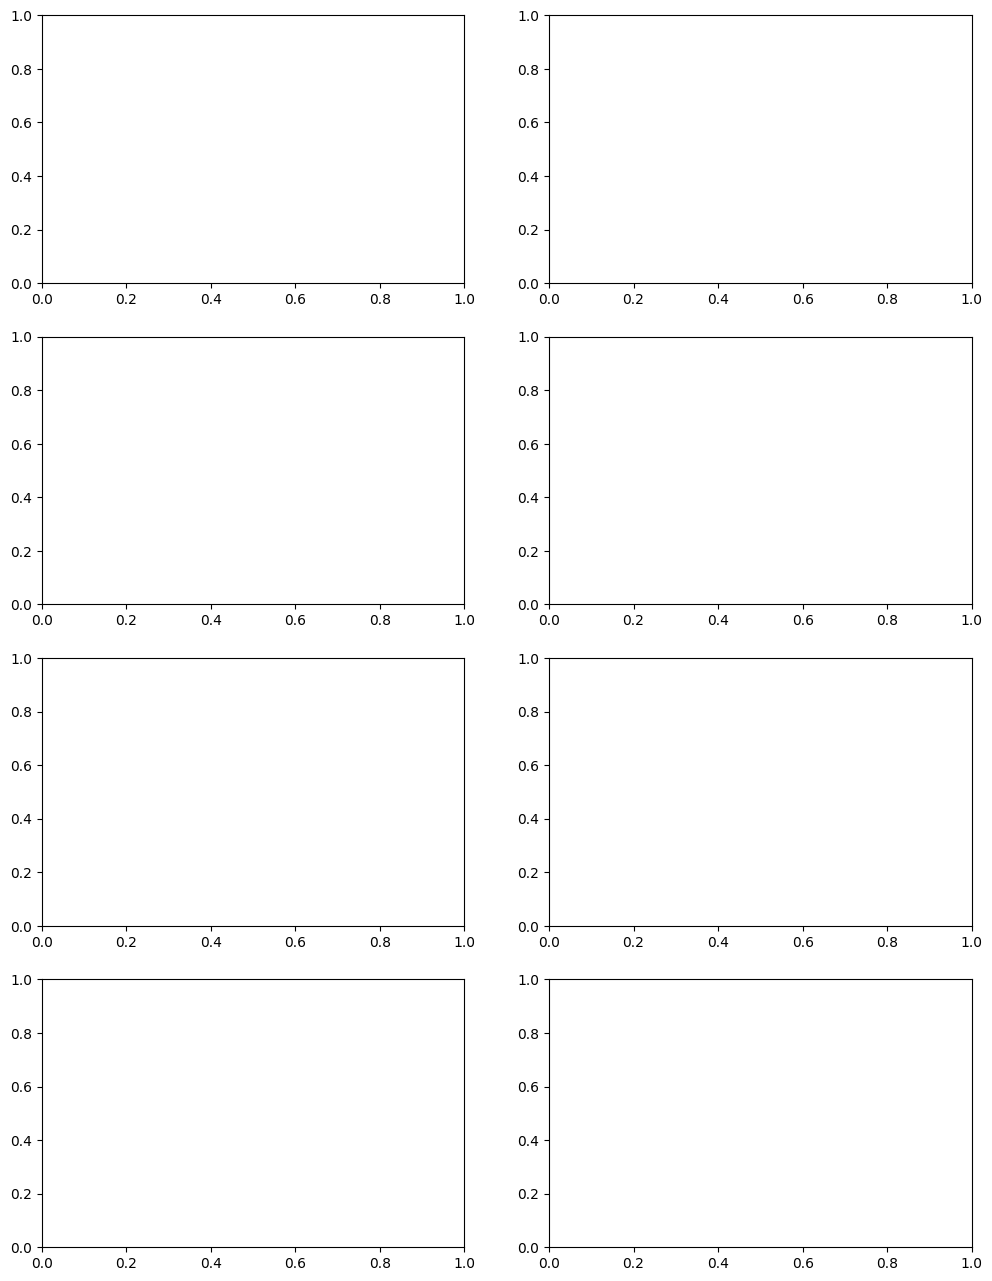

In [95]:

"""Reproduce flip-flop tasks with MR-gNODE"""
tasks = [
    ('fixed', (-1.5, 1.5), (-1.5, 1.5)),
    # ('square', (-1.5, 1.5), (-1.5, 1.5)), 
    # ('rectangle', (-2.5, 2.5), (-1.5, 1.5)),
    # ('disk', (-2.5, 2.5), (-2.5, 2.5))
]

train_configs = [
    [300, 0.0005],  # epochs, lr for fixed
    [250, 0.003],  # epochs, lr for square  
    [300, 0.005],  # epochs, lr for rectangle
    [300, 0.003]   # epochs, lr for disk
]

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
all_losses = []

for idx, (task_type, xlim, ylim) in enumerate(tasks):
    print(f"\nTraining MR-gNODE for {task_type} flip-flop task...")
    
    # Generate data
    train_data = generate_flip_flop_data_dual_region(task_type, n_trials=500, trial_length=100)
    n_epochs, lr = train_configs[idx]
    
    # Create and train model (move to GPU)
    model = BasicMRgNODE(num_regions=2, region_dim=4, input_dim=2, latent_dim=16, tau=0.01).to(device)
    # model = torch.compile(model)
    losses = train_mr_gnode_flip_flop(model, train_data, n_epochs=n_epochs, lr=lr, batch_size=32)
    all_losses.append(losses)
    
    # Plot flow fields for both regions
    for region in range(2):
        plt.sca(axes[idx, region])
        plot_flow_field_mr_gnode(model, region, task_type, xlim, ylim, grid_size=15)
        
        # Customize titles
        if task_type == 'fixed':
            title = f'(A{region+1}) Fixed: c₁, c₂ ∈ {{-1, +1}} - Region {region}'
        elif task_type == 'square':
            title = f'(B{region+1}) Square: c₁, c₂ ∈ [-1, 1] - Region {region}'
        elif task_type == 'rectangle':
            title = f'(C{region+1}) Rectangle: c₁ ∈ [-2, 2], c₂ ∈ [-1, 1] - Region {region}'
        elif task_type == 'disk':
            title = f'(D{region+1}) Disk: 1 ≤ √(c₁² + c₂²) ≤ 2 - Region {region}'
        
        plt.title(title, fontsize=10)
    
    # Clear GPU memory after each task
    if device.type == 'cuda':
        torch.cuda.empty_cache()

plt.tight_layout()
plt.show()

# Plot learning curves
plt.figure(figsize=(12, 4))

for idx, (task_type, losses) in enumerate(zip(['Fixed', 'Square', 'Rectangle', 'Disk'], all_losses)):
    plt.subplot(1, 4, idx+1)
    plt.plot(losses, linewidth=2)
    plt.title(f'{task_type} Task\nLearning Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



print(f"\n🎉 Flip-flop experiments completed!")
print(f"Final losses:")
for i, task in enumerate(['Fixed', 'Square', 'Rectangle', 'Disk']):
    print(f"  {task}: {flip_flop_losses[i][-1]:.6f}")


In [96]:
# Cell: MR-gNODE Bottleneck Analysis (Updated for Optimized Implementation)
import torch
import time
import numpy as np
from collections import defaultdict

# Assuming your optimized BasicMRgNODE is already defined
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def profile_model_components():
    """Profile different components of optimized MR-gNODE to find bottlenecks"""
    
    # Test configuration
    batch_size = 32
    num_regions = 2
    region_dim = 32
    input_dim = 2
    seq_len = 50
    dt = 0.01
    
    print(f"Profiling Optimized MR-gNODE on {device}")
    print(f"Config: batch={batch_size}, regions={num_regions}, region_dim={region_dim}, seq_len={seq_len}")
    print("="*60)
    
    # Create model and sample data
    model = BasicMRgNODE(num_regions=num_regions, region_dim=region_dim, 
                        input_dim=input_dim, latent_dim=16, tau=0.01).to(device)
    
    # Sample batch of sequences
    h_states = [torch.randn(batch_size, region_dim, device=device) for _ in range(num_regions)]
    x_inputs = [torch.randn(batch_size, input_dim, device=device) for _ in range(num_regions)]
    
    # Warmup
    print("Warming up GPU...")
    for _ in range(5):
        with torch.no_grad():
            outputs = model(h_states, x_inputs)
    
    torch.cuda.synchronize()
    
    # Profile individual forward pass components
    print("\n1. SINGLE FORWARD PASS BREAKDOWN:")
    print("-" * 40)
    
    with torch.no_grad():
        # Total forward pass
        start = time.time()
        outputs = model(h_states, x_inputs)
        torch.cuda.synchronize()
        total_forward_time = time.time() - start
        print(f"Total forward pass: {total_forward_time*1000:.2f} ms")
        
        # Communication computation (now returns tuple)
        start = time.time()
        comm_inputs, comm_info = model.compute_communication(h_states)
        torch.cuda.synchronize()
        comm_time = time.time() - start
        print(f"Communication:      {comm_time*1000:.2f} ms ({comm_time/total_forward_time*100:.1f}%)")
        
        # Flow networks
        start = time.time()
        for i in range(num_regions):
            region_input = torch.cat([h_states[i], x_inputs[i], comm_inputs[i]], dim=-1)
            flow = model.flow_nets[i](region_input)
        torch.cuda.synchronize()
        flow_time = time.time() - start
        print(f"Flow networks:      {flow_time*1000:.2f} ms ({flow_time/total_forward_time*100:.1f}%)")
        
        # Gate networks  
        start = time.time()
        for i in range(num_regions):
            region_input = torch.cat([h_states[i], x_inputs[i], comm_inputs[i]], dim=-1)
            gate = model.gate_nets[i](region_input)
        torch.cuda.synchronize()
        gate_time = time.time() - start
        print(f"Gate networks:      {gate_time*1000:.2f} ms ({gate_time/total_forward_time*100:.1f}%)")
        
        # Rate networks
        start = time.time()
        for i in range(num_regions):
            rate = model.rate_nets[i](h_states[i])
        torch.cuda.synchronize()
        rate_time = time.time() - start
        print(f"Rate networks:      {rate_time*1000:.2f} ms ({rate_time/total_forward_time*100:.1f}%)")
        
        # Variational latent
        start = time.time()
        all_h = torch.cat(h_states, dim=-1)
        z_mu = model.latent_encoder_mu(all_h)
        z_logvar = model.latent_encoder_logvar(all_h)
        z_shared = model.reparameterize(z_mu, z_logvar)
        for i in range(num_regions):
            recon = model.latent_decoders[i](z_shared)
        torch.cuda.synchronize()
        latent_time = time.time() - start
        print(f"Variational latent: {latent_time*1000:.2f} ms ({latent_time/total_forward_time*100:.1f}%)")
    
    # Profile ODE integration over sequence
    print("\n2. ODE INTEGRATION OVER SEQUENCE:")
    print("-" * 40)
    
    h_states_seq = [h_states[i].clone() for i in range(num_regions)]
    
    start = time.time()
    for t in range(seq_len):
        # Single step timing
        step_start = time.time()
        outputs = model(h_states_seq, x_inputs)
        h_dots = outputs['h_dots']
        
        # Euler step
        for i in range(num_regions):
            h_states_seq[i] = h_states_seq[i] + dt * h_dots[i]
        
        torch.cuda.synchronize()
        step_time = time.time() - step_start
        
        if t < 5:  # Print first few steps
            print(f"Step {t}: {step_time*1000:.2f} ms")
    
    total_sequence_time = time.time() - start
    avg_step_time = total_sequence_time / seq_len
    print(f"\nSequence ({seq_len} steps): {total_sequence_time:.3f} s")
    print(f"Average per step: {avg_step_time*1000:.2f} ms")
    
    # Memory usage
    print("\n3. MEMORY USAGE:")
    print("-" * 40)
    if device.type == 'cuda':
        print(f"GPU memory allocated: {torch.cuda.memory_allocated(device) / 1024**2:.1f} MB")
        print(f"GPU memory cached: {torch.cuda.memory_reserved(device) / 1024**2:.1f} MB")
    
    # Parameter count
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    # Scale analysis
    print("\n4. SCALING ANALYSIS:")
    print("-" * 40)
    
    scales = [2, 4, 8, 16]
    for scale in scales:
        scaled_batch = batch_size * scale
        h_test = [torch.randn(scaled_batch, region_dim, device=device) for _ in range(num_regions)]
        x_test = [torch.randn(scaled_batch, input_dim, device=device) for _ in range(num_regions)]
        
        # Time single forward pass
        torch.cuda.synchronize()
        start = time.time()
        with torch.no_grad():
            outputs = model(h_test, x_test)
        torch.cuda.synchronize()
        scaled_time = time.time() - start
        
        print(f"Batch size {scaled_batch:3d}: {scaled_time*1000:.2f} ms ({scaled_time/total_forward_time:.2f}x baseline)")

def profile_vectorized_communication():
    """Detailed profiling of vectorized communication computation"""
    
    print("\n" + "="*60)
    print("DETAILED VECTORIZED COMMUNICATION PROFILING")
    print("="*60)
    
    batch_size = 32
    num_regions = 4  # Test with more regions
    region_dim = 32
    
    model = BasicMRgNODE(num_regions=num_regions, region_dim=region_dim, 
                        input_dim=2, latent_dim=16, tau=0.01).to(device)
    
    h_states = [torch.randn(batch_size, region_dim, device=device) for _ in range(num_regions)]
    
    with torch.no_grad():
        # Break down vectorized communication
        print("Breaking down vectorized communication steps:")
        
        # Step 1: Stack states
        start = time.time()
        h_stacked = torch.stack(h_states, dim=1)
        torch.cuda.synchronize()
        stack_time = time.time() - start
        print(f"  Stack states:       {stack_time*1000:.2f} ms")
        
        # Step 2: Create pairwise combinations
        start = time.time()
        h_i = h_stacked.unsqueeze(2).expand(-1, -1, num_regions, -1)
        h_j = h_stacked.unsqueeze(1).expand(-1, num_regions, -1, -1)
        h_concat = torch.cat([h_i, h_j], dim=-1)
        torch.cuda.synchronize()
        pairwise_time = time.time() - start
        print(f"  Pairwise combinations: {pairwise_time*1000:.2f} ms")
        
        # Step 3: Communication gates
        start = time.time()
        mask = model.comm_mask.unsqueeze(0).unsqueeze(-1)
        h_concat_masked = h_concat * mask
        h_concat_flat = h_concat_masked.view(-1, 2 * region_dim)
        gates_flat = model.comm_gate_net(h_concat_flat)
        gates = gates_flat.view(batch_size, num_regions, num_regions, region_dim)
        torch.cuda.synchronize()
        gates_time = time.time() - start
        print(f"  Communication gates:   {gates_time*1000:.2f} ms")
        
        # Step 4: Message computation (einsum)
        start = time.time()
        h_j_expanded = h_stacked.unsqueeze(1)
        messages = torch.einsum('bfd,ftdo->btfo', h_j_expanded.squeeze(1), model.comm_weights)
        torch.cuda.synchronize()
        messages_time = time.time() - start
        print(f"  Message computation:   {messages_time*1000:.2f} ms")
        
        # Step 5: Final gating and summation
        start = time.time()
        gated_messages = gates * messages * mask
        comm_summed = torch.sum(gated_messages, dim=2)
        torch.cuda.synchronize()
        final_time = time.time() - start
        print(f"  Final gating/sum:      {final_time*1000:.2f} ms")
        
        # Total communication (for comparison)
        start = time.time()
        comm_inputs, comm_info = model.compute_communication(h_states)
        torch.cuda.synchronize()
        total_comm_time = time.time() - start
        print(f"  Total communication:   {total_comm_time*1000:.2f} ms")
        
        # Check overhead
        manual_total = stack_time + pairwise_time + gates_time + messages_time + final_time
        overhead = total_comm_time - manual_total
        print(f"  Function call overhead: {overhead*1000:.2f} ms")

def profile_different_region_counts():
    """Test how performance scales with number of regions"""
    
    print("\n" + "="*60)
    print("REGION COUNT SCALING (Optimized)")
    print("="*60)
    
    batch_size = 32
    region_dim = 32
    
    region_counts = [2, 4, 6, 8, 12]
    
    for num_regions in region_counts:
        model = BasicMRgNODE(num_regions=num_regions, region_dim=region_dim, 
                            input_dim=2, latent_dim=16, tau=0.01).to(device)
        
        h_states = [torch.randn(batch_size, region_dim, device=device) for _ in range(num_regions)]
        x_inputs = [torch.randn(batch_size, 2, device=device) for _ in range(num_regions)]
        
        # Warmup
        for _ in range(3):
            with torch.no_grad():
                outputs = model(h_states, x_inputs)
        
        # Time multiple runs
        times = []
        comm_times = []
        for _ in range(10):
            # Total forward pass
            torch.cuda.synchronize()
            start = time.time()
            with torch.no_grad():
                outputs = model(h_states, x_inputs)
            torch.cuda.synchronize()
            times.append(time.time() - start)
            
            # Just communication
            torch.cuda.synchronize()
            start = time.time()
            with torch.no_grad():
                comm_inputs, comm_info = model.compute_communication(h_states)
            torch.cuda.synchronize()
            comm_times.append(time.time() - start)
        
        avg_time = np.mean(times) * 1000
        std_time = np.std(times) * 1000
        avg_comm = np.mean(comm_times) * 1000
        
        # Communication scaling (should be O(R²))
        comm_complexity = num_regions ** 2
        comm_percentage = avg_comm / avg_time * 100
        
        print(f"{num_regions:2d} regions: {avg_time:.2f}±{std_time:.2f} ms total, "
              f"{avg_comm:.2f} ms comm ({comm_percentage:.1f}%), "
              f"O(R²) factor: {comm_complexity}")

def compare_with_baseline():
    """Compare optimized vs baseline performance"""
    
    print("\n" + "="*60)
    print("OPTIMIZATION IMPACT ANALYSIS")
    print("="*60)
    
    batch_size = 32
    num_regions = 4
    region_dim = 32
    seq_len = 20
    
    model = BasicMRgNODE(num_regions=num_regions, region_dim=region_dim, 
                        input_dim=2, latent_dim=16, tau=0.01).to(device)
    
    h_states = [torch.randn(batch_size, region_dim, device=device) for _ in range(num_regions)]
    x_inputs = [torch.randn(batch_size, 2, device=device) for _ in range(num_regions)]
    
    # Warmup
    for _ in range(5):
        with torch.no_grad():
            outputs = model(h_states, x_inputs)
    
    # Test optimized version
    torch.cuda.synchronize()
    start = time.time()
    
    h_states_opt = [h.clone() for h in h_states]
    for t in range(seq_len):
        with torch.no_grad():
            outputs = model(h_states_opt, x_inputs)
            h_dots = outputs['h_dots']
            for i in range(num_regions):
                h_states_opt[i] = h_states_opt[i] + 0.01 * h_dots[i]
    
    torch.cuda.synchronize()
    optimized_time = time.time() - start
    
    print(f"Optimized sequence ({seq_len} steps): {optimized_time:.4f} s")
    print(f"Average per step: {optimized_time/seq_len*1000:.2f} ms")
    
    # Memory efficiency
    if device.type == 'cuda':
        peak_memory = torch.cuda.max_memory_allocated(device) / 1024**2
        print(f"Peak GPU memory: {peak_memory:.1f} MB")
        
        # Reset memory counter
        torch.cuda.reset_peak_memory_stats(device)

# Run all profiling
print("Starting comprehensive profiling of optimized MR-gNODE...")
profile_model_components()
profile_vectorized_communication() 
profile_different_region_counts()
compare_with_baseline()

Starting comprehensive profiling of optimized MR-gNODE...
Profiling Optimized MR-gNODE on cuda
Config: batch=32, regions=2, region_dim=32, seq_len=50
Warming up GPU...

1. SINGLE FORWARD PASS BREAKDOWN:
----------------------------------------
Total forward pass: 1.99 ms
Communication:      0.00 ms (0.0%)
Flow networks:      1.00 ms (50.0%)
Gate networks:      0.00 ms (0.0%)
Rate networks:      0.00 ms (0.0%)
Variational latent: 1.00 ms (50.0%)

2. ODE INTEGRATION OVER SEQUENCE:
----------------------------------------
Step 0: 1.99 ms
Step 1: 1.99 ms
Step 2: 3.99 ms
Step 3: 2.00 ms
Step 4: 1.99 ms

Sequence (50 steps): 0.125 s
Average per step: 2.49 ms

3. MEMORY USAGE:
----------------------------------------
GPU memory allocated: 32.8 MB
GPU memory cached: 108.0 MB
Total parameters: 27,440
Trainable parameters: 27,440

4. SCALING ANALYSIS:
----------------------------------------
Batch size  64: 2.00 ms (1.00x baseline)
Batch size 128: 1.97 ms (0.99x baseline)
Batch size 256: 1.99 ms